# Case-day Style Clustering: GMM + BIC (auto-select k)

Clustering unit: `case_day` (e.g. `case101_day20`).

Features: intensity/style features computed from training images under `inputs/train/**/scans/*.png` (non-zero pixel histogram + summary stats).

Clustering: fit GMMs across different `k` and `covariance_type`, then choose the best model by BIC.


In [1]:
from __future__ import annotations

import importlib.util
import json
import os
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


def find_repo_root(start: Path) -> Path:
    for p in (start, *start.parents):
        if (p / "inputs" / "train.csv").exists():
            return p
        if (p / ".git").exists() and (p / "README.md").exists():
            return p
    raise RuntimeError(
        "Cannot find repo root. Start Jupyter from the project directory, or ensure inputs/train.csv exists."
    )


REPO_ROOT = find_repo_root(Path.cwd().resolve())
os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("repo_root:", REPO_ROOT)

TRAIN_DIR = Path("inputs/train")
OUT_DIR = Path("outputs/analysis")
SCRIPT = Path("analysis/scripts/cluster_case_day_gmm_bic.py")

assert TRAIN_DIR.exists(), f"Not found: {TRAIN_DIR.resolve()}"
assert SCRIPT.exists(), f"Not found: {SCRIPT.resolve()}"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("train_dir:", TRAIN_DIR)
print("out_dir:", OUT_DIR)

repo_root: /home/ubuntu/UW-Madison_GI_Tract_Image_Segmentation
train_dir: inputs/train
out_dir: outputs/analysis


## Parameters

A full scan can take a while. For a quick sanity check, set `MAX_IMAGES` to e.g. `2000`. For a full run, keep it as `0`.


In [2]:
# -------- Feature params --------
BINS = 256
CLIP_LOW_Q = 0.01
CLIP_HIGH_Q = 0.99
PER_IMAGE_SAMPLES = 256
MAX_TOTAL_SAMPLES = 2_000_000
INCLUDE_ZEROS_CLIP = False
INCLUDE_ZEROS_HIST = False

# -------- GMM sweep params --------
K_MIN = 1
K_MAX = 30
COV_TYPES = ["full", "diag", "tied", "spherical"]
PCA_VAR = 0.99
PCA_MAX_COMPONENTS = 80
N_INIT = 10
REG_COVAR = 1e-6
SEED = 42

# -------- Debug params --------
MAX_IMAGES = 5000  # 0 = full
SHUFFLE_IMAGES = False
PROGRESS_EVERY = 500

## Load helper functions from scripts (avoid re-implementing in the notebook)


In [3]:
spec = importlib.util.spec_from_file_location("cluster_case_day_gmm_bic", SCRIPT)
mod = importlib.util.module_from_spec(spec)
assert spec and spec.loader
sys.modules[spec.name] = mod
spec.loader.exec_module(mod)

iter_scan_pngs = mod.iter_scan_pngs
estimate_clip_from_samples = mod.estimate_clip_from_samples
build_case_day_features = mod.build_case_day_features
run_gmm_bic = mod.run_gmm_bic

print("loaded:", SCRIPT)

loaded: analysis/scripts/cluster_case_day_gmm_bic.py


## Enumerate scan PNGs


In [4]:
train_paths = list(iter_scan_pngs(TRAIN_DIR))
if SHUFFLE_IMAGES:
    import random

    rng = random.Random(SEED)
    rng.shuffle(train_paths)

if MAX_IMAGES and MAX_IMAGES > 0:
    train_paths = train_paths[:MAX_IMAGES]

print("scan pngs:", f"{len(train_paths):,}")
train_paths[:3]

scan pngs: 5,000


[PosixPath('inputs/train/case101/case101_day20/scans/slice_0060_266_266_1.50_1.50.png'),
 PosixPath('inputs/train/case101/case101_day20/scans/slice_0116_266_266_1.50_1.50.png'),
 PosixPath('inputs/train/case101/case101_day20/scans/slice_0085_266_266_1.50_1.50.png')]

## Estimate global clipping range (for histogram features)

By default we estimate `p1~p99` using **non-zero pixels**, which better captures "style" rather than background.


In [5]:
clip_lo, clip_hi = estimate_clip_from_samples(
    train_paths,
    nonzero_only=not INCLUDE_ZEROS_CLIP,
    per_image_samples=PER_IMAGE_SAMPLES,
    max_total_samples=MAX_TOTAL_SAMPLES,
    clip_low_q=CLIP_LOW_Q,
    clip_high_q=CLIP_HIGH_Q,
    seed=SEED,
    progress_every=PROGRESS_EVERY,
)
print("clip_lo:", clip_lo)
print("clip_hi:", clip_hi)

[clip] processed 500/5,000 images, samples=128,000
[clip] processed 1,000/5,000 images, samples=256,000
[clip] processed 1,500/5,000 images, samples=384,000
[clip] processed 2,000/5,000 images, samples=512,000
[clip] processed 2,500/5,000 images, samples=640,000
[clip] processed 3,000/5,000 images, samples=768,000
[clip] processed 3,500/5,000 images, samples=896,000
[clip] processed 4,000/5,000 images, samples=1,024,000
[clip] processed 4,500/5,000 images, samples=1,152,000
[clip] processed 5,000/5,000 images, samples=1,280,000
clip_lo: 1
clip_hi: 7872


## Build `case_day` feature table


In [6]:
feats = build_case_day_features(
    train_paths,
    bins=BINS,
    clip_lo=int(clip_lo),
    clip_hi=int(clip_hi),
    nonzero_only_hist=not INCLUDE_ZEROS_HIST,
    seed=SEED,
    progress_every=PROGRESS_EVERY,
)

print("case_days:", len(feats))
feats.head()

[feat] processed 500/5,000 images, case_days=4
[feat] processed 1,000/5,000 images, case_days=7
[feat] processed 1,500/5,000 images, case_days=11
[feat] processed 2,000/5,000 images, case_days=14
[feat] processed 2,500/5,000 images, case_days=18
[feat] processed 3,000/5,000 images, case_days=21
[feat] processed 3,500/5,000 images, case_days=25
[feat] processed 4,000/5,000 images, case_days=28
[feat] processed 4,500/5,000 images, case_days=34
[feat] processed 5,000/5,000 images, case_days=37
case_days: 37


,case_day,n_images,total_pixels,zero_pixels,zero_ratio,hist_pixels,clip_lo,clip_hi,bins,mean,...,hist_246,hist_247,hist_248,hist_249,hist_250,hist_251,hist_252,hist_253,hist_254,hist_255
0,case101_day20,144,10188864,1374196,0.134872,8814668,1,7872,256,63.726397,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
1,case101_day22,144,10188864,1425326,0.139891,8763538,1,7872,256,77.514111,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
2,case101_day26,144,10188864,1438368,0.141171,8750496,1,7872,256,907.711754,...,0.000009,0.000007,0.000005,0.000008,0.000005,0.000007,0.000006,0.000007,0.000006,0.00019
3,case101_day32,144,10188864,1568463,0.153939,8620401,1,7872,256,82.968779,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
4,case102_day0,144,16070400,4817454,0.299772,11252946,1,7872,256,64.721523,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000


In [7]:
features_csv = OUT_DIR / "case_day_intensity_features.csv"
feats.to_csv(features_csv, index=False)
print("wrote:", features_csv)

wrote: outputs/analysis/case_day_intensity_features.csv


## Scan GMM + BIC and select the best model


In [8]:
cluster_cols = (
    ["case_day", "zero_ratio", "mean", "std", "p01", "p05", "p50", "p95", "p99", "entropy"]
    + [c for c in feats.columns if c.startswith("hist_")]
)

bic_df, clusters = run_gmm_bic(
    feats[cluster_cols],
    k_min=K_MIN,
    k_max=K_MAX,
    cov_types=COV_TYPES,
    pca_var=PCA_VAR,
    pca_max_components=PCA_MAX_COMPONENTS,
    n_init=N_INIT,
    reg_covar=REG_COVAR,
    seed=SEED,
)

meta = clusters.attrs.get("gmm", {})
meta

{'best_k': 30,
 'best_covariance_type': 'spherical',
 'best_bic': -2453.6595814341645,
 'pca_kept_dims': 13,
 'pca_var_target': 0.99,
 'n_init': 10,
 'reg_covar': 1e-06,
 'seed': 42}

In [9]:
bic_csv = OUT_DIR / "gmm_bic_sweep.csv"
clusters_csv = OUT_DIR / "case_day_gmm_clusters.csv"
meta_json = OUT_DIR / "case_day_gmm_meta.json"

bic_df.to_csv(bic_csv, index=False)
clusters.to_csv(clusters_csv, index=False)
meta_json.write_text(json.dumps(meta, indent=2, ensure_ascii=False))

print("wrote:", bic_csv)
print("wrote:", clusters_csv)
print("wrote:", meta_json)

wrote: outputs/analysis/gmm_bic_sweep.csv
wrote: outputs/analysis/case_day_gmm_clusters.csv
wrote: outputs/analysis/case_day_gmm_meta.json


## BIC curves (lower is better)


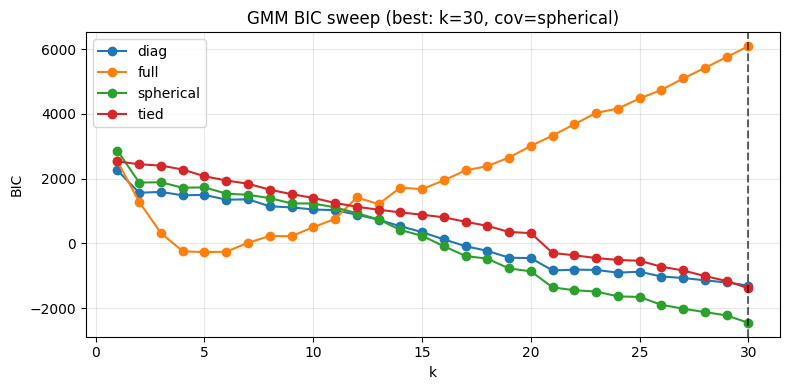

In [10]:
best_k = int(meta["best_k"])
best_cov = str(meta["best_covariance_type"])

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
for cov, g in bic_df.groupby("covariance_type"):
    g = g.sort_values("k")
    ax.plot(g["k"], g["bic"], marker="o", label=cov)

ax.axvline(best_k, color="black", linestyle="--", alpha=0.6)
ax.set_title(f"GMM BIC sweep (best: k={best_k}, cov={best_cov})")
ax.set_xlabel("k")
ax.set_ylabel("BIC")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## Clustering results overview


In [11]:
clusters["cluster_id"].value_counts().sort_index()

cluster_id
0     1
1     1
2     1
3     1
4     1
5     1
6     1
7     1
8     1
9     1
10    1
11    1
12    1
13    1
14    1
15    1
16    1
17    3
18    1
19    1
20    1
21    1
22    3
23    1
24    4
25    1
26    1
27    1
28    1
29    1
Name: count, dtype: int64

## Per-cluster mean feature statistics (for interpretation)


In [12]:
merged = feats.merge(clusters, on="case_day", how="inner")
summary_cols = ["zero_ratio", "mean", "std", "p01", "p05", "p50", "p95", "p99", "entropy"]
merged.groupby("cluster_id")[summary_cols].mean().sort_index()

,zero_ratio,mean,std,p01,p05,p50,p95,p99,entropy
cluster_id,,,,,,,,,
0,0.157433,1824.873804,2093.408052,9.854963,43.654347,944.457331,6598.641559,7851.580004,4.774167
1,0.256014,73.046272,82.732629,1.574796,3.873979,29.739788,236.865716,362.417691,1.704694
2,0.127165,1641.219150,2227.479935,8.664464,36.381270,441.652341,7206.840937,7863.377767,4.471142
3,0.437042,2349.007304,2364.300646,14.472054,53.648364,1584.411678,7113.296049,7861.878219,4.972775
4,0.131300,1634.947519,2173.391851,6.567082,28.835410,482.443510,7086.592163,7863.688733,4.460035
5,0.125181,1476.885039,1802.095239,13.746768,40.424247,700.648206,5682.502599,7178.913428,4.611123
6,0.126020,1751.014049,1978.751680,12.623223,40.081398,996.038042,6111.491066,7723.289206,4.756176
7,0.120690,2260.859987,2133.325092,43.283726,92.110984,1544.396384,6539.032085,7844.853563,5.136825
8,0.125294,1905.336095,2239.457401,15.557870,56.611562,917.144425,7274.735008,7863.615496,4.732855


## 2D visualization (PCA)

Note: this PCA(2) is for visualization; it may not be identical to the PCA used for fitting the model.


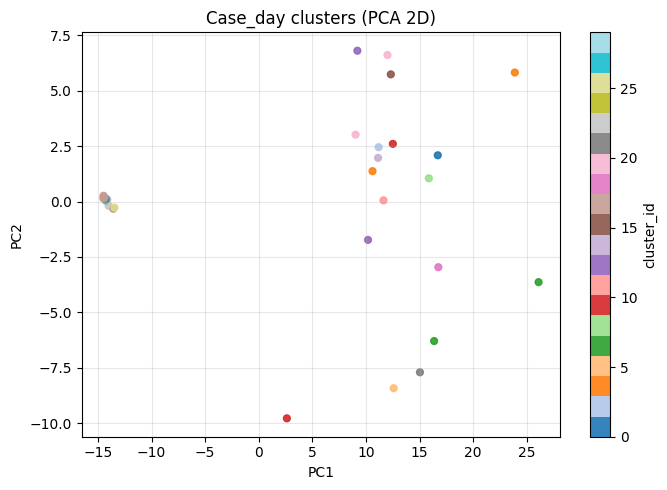

In [13]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = merged[[c for c in cluster_cols if c != "case_day"]].to_numpy(dtype=np.float64, copy=True)
Xs = StandardScaler().fit_transform(X)
Xp2 = PCA(n_components=2, random_state=SEED).fit_transform(Xs)

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
sc = ax.scatter(Xp2[:, 0], Xp2[:, 1], c=merged["cluster_id"], cmap="tab20", s=24, alpha=0.9)
ax.set_title("Case_day clusters (PCA 2D)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.grid(True, alpha=0.3)
plt.colorbar(sc, ax=ax, label="cluster_id")
plt.tight_layout()
plt.show()